In [8]:
from pyomo.environ import *
import pandas as pd
from pathlib import Path

BASE = Path.cwd()

DA_CSV_PATH = BASE /"DA_LMPs_Data/PJM/df_DA_PJM_AECO_2025_DA_hourly.csv"
RT_CSV_PATH = BASE /"RT_LMPs_Data/PJM/df_RT_PJM_AECO_2025_RT_5min.csv"
REG_CSV_PATH = BASE /"reg_zone_prelim_bill_PJM_January_2025.csv"
SIGNALS_CSV_PATH = BASE /"AGC Signal for Regulation/PJM/01_2025_avg_5min_pos_neg.csv"
EV_CSV_PATH = BASE /"EV_fleet.csv"

#Time Window used
TZ = "America/New_York"
pt_start = pd.Timestamp("2025-01-15 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-01-16 14:00", tz=TZ)
# Convert to UTC
utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")

#Load Datasets
df_DA_all = pd.read_csv(DA_CSV_PATH)
df_RT_all = pd.read_csv(RT_CSV_PATH)
df_REG_all = pd.read_csv(REG_CSV_PATH)
df_EV = pd.read_csv(EV_CSV_PATH)

# Parse the timestamp columns (these files are already UTC with offset)
df_DA_all["interval_start_utc"] = pd.to_datetime(df_DA_all["interval_start_utc"], utc=True)
df_RT_all["interval_start_utc"] = pd.to_datetime(df_RT_all["interval_start_utc"], utc=True)

df_DA = df_DA_all.loc[
    (df_DA_all["interval_start_utc"] >= utc_start) &
    (df_DA_all["interval_start_utc"] <  utc_end)
].sort_values("interval_start_utc").reset_index(drop=True)

df_RT = df_RT_all.loc[
    (df_RT_all["interval_start_utc"] >= utc_start) &
    (df_RT_all["interval_start_utc"] <  utc_end)
].sort_values("interval_start_utc").reset_index(drop=True)

df_REG_all["datetime_beginning_ept"] = pd.to_datetime(df_REG_all["datetime_beginning_ept"])
df_REG_all["datetime_beginning_ept"] = df_REG_all["datetime_beginning_ept"].dt.tz_localize(TZ)

df_REG = df_REG_all.loc[
    (df_REG_all["datetime_beginning_ept"] >= pt_start) &
    (df_REG_all["datetime_beginning_ept"] <  pt_end)
].sort_values("datetime_beginning_ept").reset_index(drop=True)

EV_ids = df_EV["EV"].tolist()

E_bat_max_dict = df_EV.set_index("EV")["E_bat_max (kWh)"].to_dict()
n_dict         = df_EV.set_index("EV")["n"].to_dict()
Pchrg_dict     = df_EV.set_index("EV")["Pchrg (kW)"].to_dict()
SOEa_dict      = df_EV.set_index("EV")["SOEa"].to_dict()
SOEd_dict      = df_EV.set_index("EV")["SOEd"].to_dict()

Ta_hr = df_EV.set_index("EV")["Ta_hr"].to_dict()
Td_hr = df_EV.set_index("EV")["Td_hr"].to_dict()

T = 24                  # hours
K = 12                  # 5-minute steps per hour
NK = T * K
t0 = 14                 # initial hour of day
k0 = t0 * K             # initial 5-minute interval of day

# Align price dictionaries to absolute index sets
t_keys = list(range(t0, t0 + T))          # 14..37
k_keys = list(range(k0, k0 + NK))         # 168..455

# 1) DA prices: map 0-based rows -> absolute hours 14..37
lmp_DA = {t_keys[i]: float(df_DA.loc[i, "lmp"]) for i in range(T)}

# 2) RT 5-min prices: map 0-based rows -> absolute sub-steps 168..455
lmp_RT = {k_keys[i]: float(df_RT.loc[i, "lmp"]) for i in range(NK)}

# 3) Hourly RT averages over contiguous 12×5-min windows
lt_RTE = {}
for i, t in enumerate(t_keys):
    s = i * K
    e = (i + 1) * K
    lt_RTE[t] = float(df_RT.loc[s:e - 1, "lmp"].mean())

# Regulation RT clearing price
lt_RMCCP = {t_keys[i]: float(df_REG.loc[i, "rmccp"]) for i in range(T)} #capacity
lt_RMPCP = {t_keys[i]: float(df_REG.loc[i, "rmpcp"]) for i in range(T)} #mileage

# RT Signals
RT_Signals = pd.read_csv(SIGNALS_CSV_PATH)
cols = ["1/15/2025_pos", "1/15/2025_neg"]
RT_Signals[cols] = RT_Signals[cols].fillna(0.0)

r_pos_dict = {k_keys[i]: float(RT_Signals.loc[i, "1/15/2025_pos"]) for i in range(NK)}
r_neg_dict = {k_keys[i]: float(RT_Signals.loc[i, "1/15/2025_neg"]) for i in range(NK)}

def r_dc_pos_init(m, k, w):
    return r_pos_dict[k]

def r_dc_neg_init(m, k, w):
    return -r_neg_dict[k]

def hour_from_k(k):
    return t0 + (k - k0) // K

## Build model
model = ConcreteModel()

## Sets
model.IDX_i = model.IDX_i = Set(initialize=EV_ids)
model.IDX_t = RangeSet(t0, t0 + T - 1)           
model.IDX_k = RangeSet(k0, k0 + NK - 1)          
model.IDX_w = Set(initialize=['w1'])             # single scenario

## Parameters
model.Dt     = Param(initialize=1/12)  # 5 minutes in hours
model.prob_w = Param(initialize=1.0)

# LMP Prices
model.l_DAE  = Param(model.IDX_t, initialize=lmp_DA)   # $/MWh
model.lk_RTE = Param(model.IDX_k, initialize=lmp_RT)   # $/MWh
model.lt_RTE = Param(model.IDX_t, initialize=lt_RTE)   # $/MWh

# Regulation Prices
model.lt_RMCCP = Param(model.IDX_t, initialize=lt_RMCCP)  # capacity price
model.lt_RMMCP = Param(model.IDX_t, initialize=lt_RMPCP)  # mileage price

#Reg Parameters
model.s_perf = Param(model.IDX_t, initialize = 0.985)
model.a_mil = Param(model.IDX_t, initialize = 1)

# EV fleet parameters
model.E_bat_max = Param(model.IDX_i, initialize=E_bat_max_dict)
model.n         = Param(model.IDX_i, initialize=n_dict)
model.Pchrg     = Param(model.IDX_i, initialize=Pchrg_dict)
model.SOEa      = Param(model.IDX_i, initialize=SOEa_dict)
model.SOEd      = Param(model.IDX_i, initialize=SOEd_dict)
model.SOEcc_cv  = Param(initialize=0.85)

# Regulation deployment ratios r 
model.r_pos = Param(model.IDX_k, model.IDX_w, initialize=r_dc_pos_init)
model.r_neg = Param(model.IDX_k, model.IDX_w, initialize= r_dc_neg_init)

# Availability windows (hours counted from 14:00 of the first day;)
Ta_k = {i: int(Ta_hr[i]) * K for i in EV_ids}
Td_k = {i: int(Td_hr[i]) * K for i in EV_ids}

# Convert to absolute sub-steps
#Ta_k = {i: Ta_hr[i] * K for i in Ta_hr}
#Td_k = {i: Td_hr[i] * K for i in Td_hr}

def u_init(model, i, k):
    return 1 if (k >= Ta_k[i] and k < Td_k[i]) else 0

model.u = Param(model.IDX_i, model.IDX_k, initialize=u_init, within=Binary)

# DART Spread Penalty settings
dev = 0.3
max_gap = max(0.0, max(lt_RTE[t] - lmp_DA[t] for t in t_keys))
M_fixed = 1.01 / (1.0 - dev) * max_gap
model.M = Param(initialize=M_fixed)   # $/MWh

## Decision variables
model.E_DA       = Var(model.IDX_t, within=NonNegativeReals)                             # MWh
model.E_RT       = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)                # MWh (agg over EVs)
model.E_i_RT     = Var(model.IDX_i, model.IDX_k, model.IDX_w, within=NonNegativeReals)   # kWh
model.SOE        = Var(model.IDX_i, model.IDX_k, model.IDX_w, bounds=(0, 1))             # fraction
model.P_RT_max   = Var(model.IDX_i, model.IDX_k, model.IDX_w, within=NonNegativeReals)   # kW
model.DE         = Var(model.IDX_t, model.IDX_w)  # signed deviation (MWh) # aux
model.DE_U       = Var(model.IDX_t, model.IDX_w)
model.DE_I       = Var(model.IDX_t, model.IDX_w)
model.DE_U_Up    = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.DE_U_Down  = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.Pnlty_UUp   = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.Pnlty_UDown = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.b          = Var(model.IDX_t, model.IDX_w, within=Binary)
#model.R_DA_pos   = Var(model.IDX_t, within=NonNegativeReals)
#model.R_DA_neg   = Var(model.IDX_t, within=NonNegativeReals)
model.R_RT_pos   = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.R_RT_neg   = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.E_RT_R_neg = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)
model.E_RT_R_pos = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)

## Constraints
def DE_constraint(model, t, w):
    k0_t, k1_t = t * K, (t + 1) * K
    return model.DE[t, w] == model.E_DA[t] - sum(model.E_RT[k, w] for k in range(k0_t, k1_t))
model.DEcon = Constraint(model.IDX_t, model.IDX_w, rule=DE_constraint)

model.DE2con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.DE[t, w] == m.DE_U[t, w] + m.DE_I[t, w])
model.DE3con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.DE_U[t, w] == m.DE_U_Up[t, w] - m.DE_U_Down[t, w])

def DEI_constraint(model, t, w):
    k0_t, k1_t = t * K, (t + 1) * K
    return model.DE_I[t, w] == sum(model.E_RT_R_pos[k, w] - model.E_RT_R_neg[k, w] for k in range(k0_t, k1_t))
model.DEIcon = Constraint(model.IDX_t, model.IDX_w, rule=DEI_constraint)

def r_dcpos_constraint(model, k, w):
    t = hour_from_k(k)
    return model.E_RT_R_pos[k, w] == model.r_pos[k, w] * model.R_RT_pos[t, w]*model.Dt
model.Rdcposcon = Constraint(model.IDX_k, model.IDX_w, rule=r_dcpos_constraint)

def r_dcneg_constraint(model, k, w):
    t = hour_from_k(k)
    return model.E_RT_R_neg[k, w] == model.r_neg[k, w] * model.R_RT_neg[t, w]*model.Dt
model.Rdcnegcon = Constraint(model.IDX_k, model.IDX_w, rule=r_dcneg_constraint)


def Rpos_constraint(model, t, w):
    return model.R_RT_pos[t, w] <= model.E_DA[t] - model.DE_U[t, w] #divided by 1h to refer to MW
model.Rposcon = Constraint(model.IDX_t, model.IDX_w, rule=Rpos_constraint)

def Rneg_constraint(model, t, w):
    k0_t, k1_t = t * K, (t + 1) * K
    return model.R_RT_neg[t, w] <= (
        sum(model.u[i, k] * model.P_RT_max[i, k, w] for i in model.IDX_i for k in range(k0_t, k1_t))
        - (model.E_DA[t] - model.DE_U[t, w])
    )
model.Rnegcon = Constraint(model.IDX_t, model.IDX_w, rule=Rneg_constraint)

#def R3_constraint(model, t, w):
    #return model.R_RT_pos[t, w] <= model.R_DA_pos[t]
#model.R3con = Constraint(model.IDX_t, model.IDX_w, rule=R3_constraint)

# Activate only one side depending on b
def de_up_limit(m, t, w):
    return m.DE_U_Up[t, w] <= 10**6 * m.b[t, w]
model.de_up_limit = Constraint(model.IDX_t, model.IDX_w, rule=de_up_limit)

def de_dn_limit(m, t, w):
    return m.DE_U_Down[t, w] <= 10**6 * (1 - m.b[t, w])
model.de_dn_limit = Constraint(model.IDX_t, model.IDX_w, rule=de_dn_limit)

def de_pos_enforce(m, t, w):
    return m.DE[t, w] >= -10**6 * (1 - m.b[t, w])
model.de_pos_enforce = Constraint(model.IDX_t, model.IDX_w, rule=de_pos_enforce)

def de_neg_enforce(m, t, w):
    return m.DE[t, w] <= 10**6 * m.b[t, w]
model.de_neg_enforce = Constraint(model.IDX_t, model.IDX_w, rule=de_neg_enforce)

model.EVcon = Constraint(
    model.IDX_k, model.IDX_w,
    rule=lambda m, k, w: m.E_RT[k, w] == sum(m.E_i_RT[i, k, w] for i in m.IDX_i) / 1000.0
)

model.EV2con = Constraint(
    model.IDX_i, model.IDX_k, model.IDX_w,
    rule=lambda m, i, k, w: m.E_i_RT[i, k, w] <= m.P_RT_max[i, k, w] * m.Dt
)

model.EV3con = Constraint(
    model.IDX_i, model.IDX_k, model.IDX_w,
    rule=lambda m, i, k, w: m.P_RT_max[i, k, w] <= m.u[i, k] * m.Pchrg[i]
)

def EV4_rule(model, i, k, w):
    return model.P_RT_max[i, k, w] <= model.u[i, k] * model.Pchrg[i] * ((1 - model.SOE[i, k, w]) / (1 - model.SOEcc_cv))
model.EV4con = Constraint(model.IDX_i, model.IDX_k, model.IDX_w, rule=EV4_rule)

def SOE_init_k0(model, i, w):
    return model.SOE[i, k0, w] == model.SOEa[i]
model.SOE_init_k0 = Constraint(model.IDX_i, model.IDX_w, rule=SOE_init_k0)

def EV5_rule(model, i, k, w):
    if k == k0 + NK - 1:
        return Constraint.Skip
    return model.SOE[i, k + 1, w] == model.SOE[i, k, w] + (model.n[i] / model.E_bat_max[i]) * model.E_i_RT[i, k, w]
model.EV5con = Constraint(model.IDX_i, model.IDX_k, model.IDX_w, rule=EV5_rule)

def EV6_rule(model, i, w):
    k_dep = Td_k[i] - 1
    if k0 <= k_dep < k0 + NK:
        return model.SOE[i, k_dep, w] == model.SOEd[i]
    return Constraint.Skip
model.EV6con = Constraint(model.IDX_i, model.IDX_w, rule=EV6_rule)

model.Pcon  = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.Pnlty_UUp[t, w] >= 0)
model.P3con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.Pnlty_UDown[t, w] >= 0)
model.P2con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.Pnlty_UUp[t, w] >= m.M * (m.DE_U_Up[t, w] - dev * m.E_DA[t]))
model.P4con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.Pnlty_UDown[t, w] >= m.M * (m.DE_U_Down[t, w] - dev * m.E_DA[t]))

## Objective Function
def objFunc_(model):
    w = 'w1'
    return sum(
        -model.l_DAE[t] * model.E_DA[t]
        + model.lt_RMCCP[t] * (model.R_RT_pos[t, w]+model.R_RT_neg[t, w])*model.s_perf[t]#hourly interval MW from regulation are multiplied with 1h
        + model.lt_RMMCP[t] * (model.R_RT_pos[t, w]+model.R_RT_neg[t, w])*model.s_perf[t]*model.a_mil[t]
        + model.lt_RTE[t] * model.DE[t, w]
        - model.Pnlty_UUp[t, w] - model.Pnlty_UDown[t, w] #Penalty for reg deployment shortage needs to be included
        for t in model.IDX_t
    )

model.cost = Objective(rule=objFunc_, sense=maximize)

#solve
solver = SolverFactory("gurobi")

#GUROBI options
solver.options["MIPGap"] = 1e-4
solver.options["TimeLimit"] = 300  # seconds

results = solver.solve(model, tee=True)
print(results.solver.status, results.solver.termination_condition)
print(f"Total Profit: ${value(model.cost):.2f}")

#Results printed
da_series = pd.Series({t: value(model.E_DA[t]) for t in model.IDX_t}, name="E_DA_MWh")
de_series = pd.Series({t: value(model.DE[t, 'w1']) for t in model.IDX_t}, name="DE_MWh")
#reg_series = pd.Series({t: value(model.R_DA_pos[t]) for t in model.IDX_t}, name="R_DApos_MWh")
#reg2_series = pd.Series({t: value(model.R_DA_neg[t]) for t in model.IDX_t}, name="R_DAneg_MWh")
reg_rt_series = pd.Series({t: value(model.R_RT_pos[t, 'w1']) for t in model.IDX_t}, name="R_RTpos_MWh")
reg_rt_series2 = pd.Series({t: value(model.R_RT_neg[t, 'w1']) for t in model.IDX_t}, name="R_RTneg_MWh")
prices_da = pd.Series({t: value(model.l_DAE[t]) for t in model.IDX_t}, name="DA_$perMWh")
prices_rt = pd.Series({t: value(model.lt_RTE[t]) for t in model.IDX_t}, name="RTavg_$perMWh")
prices_reg = pd.Series({t: value(model.lt_RMCCP[t]) for t in model.IDX_t}, name="Reg_RMCCP_avg_$perMWh")

out = pd.concat(
    [prices_da, prices_rt, prices_reg, da_series, de_series, reg_rt_series,reg_rt_series2],
    axis=1
)

print(out.head(24).round(3))

OUTPUT_PATH = BASE / "EV_aggregator_energy&reg_sched_2025_01_15.csv"

out.to_csv(OUTPUT_PATH, index=True)

print(f"\nResults saved to:\n{OUTPUT_PATH}")

C:\Users\hsofi\AppData\Local\Temp\ipykernel_25740\3707509779.py:41: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_REG_all["datetime_beginning_ept"] = pd.to_datetime(df_REG_all["datetime_beginning_ept"])


Read LP format model from file C:\Users\hsofi\AppData\Local\Temp\tmpupnfr3r5.pyomo.lp
Reading time = 1.12 seconds
x1: 231800 rows, 173928 columns, 525023 nonzeros
Set parameter MIPGap to value 0.0001
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) Ultra 7 165U, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 14 logical processors, using up to 14 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 231800 rows, 173928 columns and 525023 nonzeros (Max)
Model fingerprint: 0xdef28aaa
Model has 144 linear objective coefficients
Variable types: 173904 continuous, 24 integer (24 binary)
Coefficient statistics:
  Matrix range     [3e-04, 1e+06]
  Objective range  [1e+00, 2e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 1e+06]

Presolve removed 230605 rows and 172718 columns
Presolve time: 1.15s
Presolved: 1195 rows, 1210 columns, 4495 nonzer

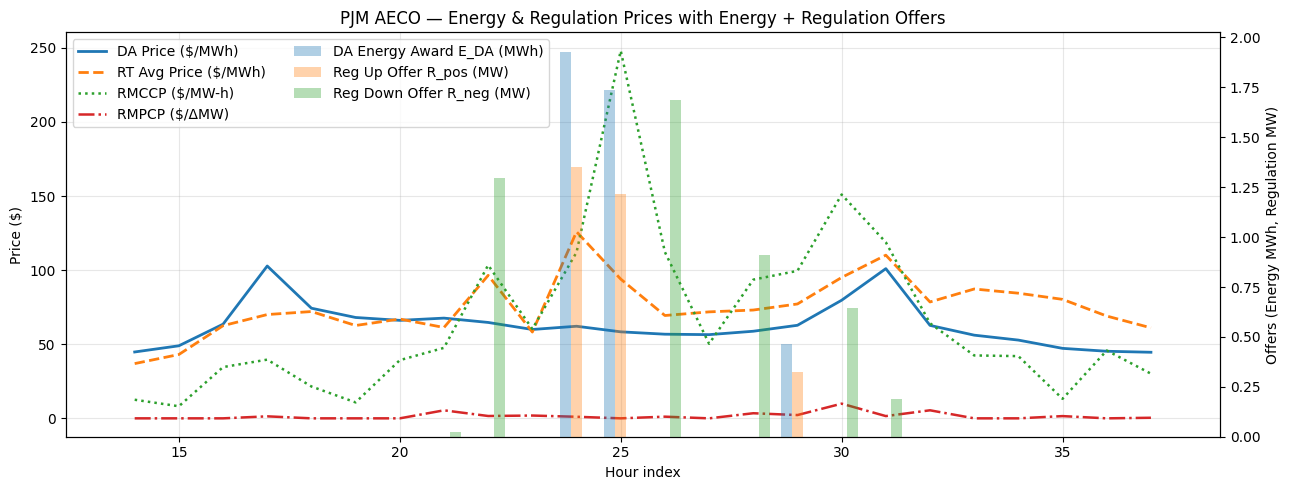

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from pyomo.environ import value

t_list = list(model.IDX_t)
w = "w1"

# -----------------------------
# Series from model
# -----------------------------
DA_price = pd.Series({t: value(model.l_DAE[t]) for t in t_list}, name="DA $/MWh")
RT_price = pd.Series({t: value(model.lt_RTE[t]) for t in t_list}, name="RT avg $/MWh")

RMCCP = pd.Series({t: value(model.lt_RMCCP[t]) for t in t_list}, name="RMCCP $/MW-h")
RMPCP = pd.Series({t: value(model.lt_RMMCP[t]) for t in t_list}, name="RMPCP $/ΔMW")

E_DA = pd.Series({t: value(model.E_DA[t]) for t in t_list}, name="E_DA (MWh)")
R_pos = pd.Series({t: value(model.R_RT_pos[t, w]) for t in t_list}, name="Reg Up (MW)")
R_neg = pd.Series({t: value(model.R_RT_neg[t, w]) for t in t_list}, name="Reg Down (MW)")

# -----------------------------
# Plot
# -----------------------------
fig, ax1 = plt.subplots(figsize=(13, 5))

# Left axis: prices
ax1.plot(t_list, DA_price, linewidth=2, label="DA Price ($/MWh)")
ax1.plot(t_list, RT_price, linewidth=2, linestyle="--", label="RT Avg Price ($/MWh)")

ax1.plot(t_list, RMCCP, linewidth=1.8, linestyle=":", label="RMCCP ($/MW-h)")
ax1.plot(t_list, RMPCP, linewidth=1.8, linestyle="-.", label="RMPCP ($/ΔMW)")

ax1.set_xlabel("Hour index")
ax1.set_ylabel("Price ($)")
ax1.grid(True, alpha=0.3)

# Right axis: offers (different units, same axis visually)
ax2 = ax1.twinx()
ax2.set_ylabel("Offers (Energy MWh, Regulation MW)")

# Bars: energy + regulation (offset so they don't overlap)
bw = 0.25
ax2.bar([t - bw for t in t_list], E_DA, width=bw, alpha=0.35, label="DA Energy Award E_DA (MWh)")
ax2.bar([t for t in t_list], R_pos, width=bw, alpha=0.35, label="Reg Up Offer R_pos (MW)")
ax2.bar([t + bw for t in t_list], R_neg, width=bw, alpha=0.35, label="Reg Down Offer R_neg (MW)")

# One combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", ncol=2)

plt.title("PJM AECO — Energy & Regulation Prices with Energy + Regulation Offers")
plt.tight_layout()
plt.show()


In [23]:
from pyomo.environ import *
import pandas as pd

DA_CSV_PATH = r"C:\Users\hsofi\EVC\df_DA_PJM_AECO_2025_DA_hourly.csv"
RT_CSV_PATH = r"C:\Users\hsofi\EVC\df_RT_PJM_AECO_2025_RT_5min.csv"
REG_CSV_PATH = r"C:\Users\hsofi\EVC\reg_zone_prelim_bill_PJM_January_2025.csv"

#Time Window used
TZ = "America/New_York"
pt_start = pd.Timestamp("2025-01-15 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-01-16 14:00", tz=TZ)
# Convert to UTC
utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")

#Load DA & RT LMP Datasets for selected hub/zone
df_DA_all = pd.read_csv(DA_CSV_PATH)
df_RT_all = pd.read_csv(RT_CSV_PATH)
df_REG_all = pd.read_csv(REG_CSV_PATH)

# Parse the timestamp columns (these files are already UTC with offset)
df_DA_all["interval_start_utc"] = pd.to_datetime(df_DA_all["interval_start_utc"], utc=True)
df_RT_all["interval_start_utc"] = pd.to_datetime(df_RT_all["interval_start_utc"], utc=True)

df_DA = df_DA_all.loc[
    (df_DA_all["interval_start_utc"] >= utc_start) &
    (df_DA_all["interval_start_utc"] <  utc_end)
].sort_values("interval_start_utc").reset_index(drop=True)

df_RT = df_RT_all.loc[
    (df_RT_all["interval_start_utc"] >= utc_start) &
    (df_RT_all["interval_start_utc"] <  utc_end)
].sort_values("interval_start_utc").reset_index(drop=True)

df_REG_all["datetime_beginning_ept"] = pd.to_datetime(df_REG_all["datetime_beginning_ept"])
df_REG_all["datetime_beginning_ept"] = df_REG_all["datetime_beginning_ept"].dt.tz_localize(TZ)

df_REG = df_REG_all.loc[
    (df_REG_all["datetime_beginning_ept"] >= pt_start) &
    (df_REG_all["datetime_beginning_ept"] <  pt_end)
].sort_values("datetime_beginning_ept").reset_index(drop=True)

T = 24                  # hours
K = 12                  # 5-minute steps per hour
NK = T * K
t0 = 14                 # initial hour of day
k0 = t0 * K             # initial 5-minute interval of day
W =['w1','w2','w3']

# Align price dictionaries to absolute index sets
t_keys = list(range(t0, t0 + T))          # 14..37
k_keys = list(range(k0, k0 + NK))         # 168..455

# 1) DA prices: map 0-based rows -> absolute hours 14..37
lmp_DA = {t_keys[i]: float(df_DA.loc[i, "lmp"]) for i in range(T)}

# 2) RT 5-min prices: map 0-based rows -> absolute sub-steps 168..455
lmp_RT = {k_keys[i]: float(df_RT.loc[i, "lmp"]) for i in range(NK)}

# 3) Hourly RT averages over contiguous 12×5-min windows
lt_RTE = {}
for i, t in enumerate(t_keys):
    s = i * K
    e = (i + 1) * K
    lt_RTE[t] = float(df_RT.loc[s:e - 1, "lmp"].mean())

# Regulation RT clearing price
lt_RMCCP = {t_keys[i]: float(df_REG.loc[i, "rmccp"]) for i in range(T)} #capacity
lt_RMPCP = {t_keys[i]: float(df_REG.loc[i, "rmpcp"]) for i in range(T)} #mileage

# RT Signals
RT_Signals = pd.read_csv("01_2025_avg_5min_pos_neg.csv")
cols = ["1/15/2025_pos", "1/15/2025_neg"]
RT_Signals[cols] = RT_Signals[cols].fillna(0.0)

r_pos_dict = {k_keys[i]: float(RT_Signals.loc[i, "1/15/2025_pos"]) for i in range(NK)}
r_neg_dict = {k_keys[i]: float(RT_Signals.loc[i, "1/15/2025_neg"]) for i in range(NK)}

def r_dc_pos_init(m, k, w):
    return r_pos_dict[k]

def r_dc_neg_init(m, k, w):
    return -r_neg_dict[k]

def hour_from_k(k):
    return t0 + (k - k0) // K

## Build model
model = ConcreteModel()

## Sets
model.IDX_i = Set(initialize=['EV1', 'EV2', 'EV3', 'EV4', 'EV5'])
model.IDX_t = RangeSet(t0, t0 + T - 1)           # 14..37
model.IDX_k = RangeSet(k0, k0 + NK - 1)          # 168..455
model.IDX_w = Set(initialize= W)             # single scenario

## Parameters
model.Dt     = Param(initialize=1/12)  # 5 minutes in hours
model.prob_w = Param(model.IDX_w, initialize={'w1': 1/3, 'w2': 1/3, 'w3': 1/3})

#Scenario Generation
price_mult = {"w1": 1.0, "w2": 1.05, "w3": 0.95}
signal_mult = {"w1": 1.0, "w2": 1.10, "w3": 0.90}
lmp_RT_w = {}
lt_RTE_w = {}
rmccp_w  = {}
rmpcp_w  = {}
r_pos_w  = {}
r_neg_w  = {}

for w in W:
    # RT 5-min prices
    for i, k in enumerate(k_keys):
        base = float(df_RT.loc[i, "lmp"])
        lmp_RT_w[(k, w)] = price_mult[w] * base

    # Hourly RT avg (from scenario RT prices)
    for i, t in enumerate(t_keys):
        ks = k_keys[i*K:(i+1)*K]
        lt_RTE_w[(t, w)] = sum(lmp_RT_w[(k, w)] for k in ks) / K

    # Reg prices (you can keep deterministic or scale them too)
    for i, t in enumerate(t_keys):
        rmccp_w[(t, w)] = float(df_REG.loc[i, "rmccp"])   # deterministic across scenarios
        rmpcp_w[(t, w)] = float(df_REG.loc[i, "rmpcp"])

    # Signals
    for i, k in enumerate(k_keys):
        r_pos_w[(k, w)] = signal_mult[w] * float(RT_Signals.loc[i, "1/15/2025_pos"])
        r_neg_w[(k, w)] = -signal_mult[w] * float(RT_Signals.loc[i, "1/15/2025_neg"])

# LMP Prices
model.l_DAE  = Param(model.IDX_t, initialize=lmp_DA)   # $/MWh
model.lk_RTE = Param(model.IDX_k, model.IDX_w, initialize=lambda m, k, w: lmp_RT_w[(k, w)])
model.lt_RTE = Param(model.IDX_t, model.IDX_w, initialize=lambda m, t, w: lt_RTE_w[(t, w)])

model.lt_RMCCP = Param(model.IDX_t, model.IDX_w, initialize=lambda m, t, w: rmccp_w[(t, w)])
model.lt_RMMCP = Param(model.IDX_t, model.IDX_w, initialize=lambda m, t, w: rmpcp_w[(t, w)])

model.r_pos = Param(model.IDX_k, model.IDX_w, initialize=lambda m, k, w: r_pos_w[(k, w)])
model.r_neg = Param(model.IDX_k, model.IDX_w, initialize=lambda m, k, w: r_neg_w[(k, w)])

#Reg Parameters
model.s_perf = Param(model.IDX_t, initialize = 0.985)
model.a_mil = Param(model.IDX_t, initialize = 1)

# EV fleet parameters
model.E_bat_max = Param(model.IDX_i, initialize={'EV1': 20, 'EV2': 20, 'EV3': 20, 'EV4': 20, 'EV5': 20})  # kWh
model.n         = Param(model.IDX_i, initialize={'EV1': 0.9, 'EV2': 0.9, 'EV3': 0.9, 'EV4': 0.9, 'EV5': 0.9})
model.Pchrg     = Param(model.IDX_i, initialize={'EV1': 3, 'EV2': 3, 'EV3': 3, 'EV4': 3, 'EV5': 3})       # kW
model.SOEa      = Param(model.IDX_i, initialize={'EV1': 0.2, 'EV2': 0.1, 'EV3': 0.3, 'EV4': 0.4, 'EV5': 0.2})
model.SOEd      = Param(model.IDX_i, initialize={'EV1': 0.95, 'EV2': 0.95, 'EV3': 0.95, 'EV4': 0.95, 'EV5': 0.95})
model.SOEcc_cv  = Param(initialize=0.85)

# Availability windows (hours counted from 14:00 of the first day;)
Ta_hr = {'EV1': 17, 'EV2': 18, 'EV3': 19, 'EV4': 19, 'EV5': 18}  # plug-in hour
Td_hr = {'EV1': 31, 'EV2': 31, 'EV3': 32, 'EV4': 31, 'EV5': 30}  # unplug hour

# Convert to absolute sub-steps
Ta_k = {i: Ta_hr[i] * K for i in Ta_hr}
Td_k = {i: Td_hr[i] * K for i in Td_hr}

def u_init(model, i, k):
    return 1 if (k >= Ta_k[i] and k < Td_k[i]) else 0

model.u = Param(model.IDX_i, model.IDX_k, initialize=u_init, within=Binary)

# DART Spread Penalty settings
dev = 0.3
max_gap = max(0.0, max(lt_RTE_w[(t,w)] - lmp_DA[t] for t in t_keys for w in W))
M_fixed = 1.01 / (1.0 - dev) * max_gap
model.M = Param(initialize=M_fixed)   # $/MWh

## Decision variables
model.E_DA       = Var(model.IDX_t, within=NonNegativeReals)                             # MWh
model.E_RT       = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)                # MWh (agg over EVs)
model.E_i_RT     = Var(model.IDX_i, model.IDX_k, model.IDX_w, within=NonNegativeReals)   # kWh
model.SOE        = Var(model.IDX_i, model.IDX_k, model.IDX_w, bounds=(0, 1))             # fraction
model.P_RT_max   = Var(model.IDX_i, model.IDX_k, model.IDX_w, within=NonNegativeReals)   # kW
model.DE         = Var(model.IDX_t, model.IDX_w)  # signed deviation (MWh) # aux
model.DE_U       = Var(model.IDX_t, model.IDX_w)
model.DE_I       = Var(model.IDX_t, model.IDX_w)
model.DE_U_Up    = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.DE_U_Down  = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.Pnlty_UUp   = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.Pnlty_UDown = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.b          = Var(model.IDX_t, model.IDX_w, within=Binary)
#model.R_DA_pos   = Var(model.IDX_t, within=NonNegativeReals)
#model.R_DA_neg   = Var(model.IDX_t, within=NonNegativeReals)
model.R_RT_pos   = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.R_RT_neg   = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.E_RT_R_neg = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)
model.E_RT_R_pos = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)

## Constraints
def DE_constraint(model, t, w):
    k0_t, k1_t = t * K, (t + 1) * K
    return model.DE[t, w] == model.E_DA[t] - sum(model.E_RT[k, w] for k in range(k0_t, k1_t))
model.DEcon = Constraint(model.IDX_t, model.IDX_w, rule=DE_constraint)

model.DE2con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.DE[t, w] == m.DE_U[t, w] + m.DE_I[t, w])
model.DE3con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.DE_U[t, w] == m.DE_U_Up[t, w] - m.DE_U_Down[t, w])

def DEI_constraint(model, t, w):
    k0_t, k1_t = t * K, (t + 1) * K
    return model.DE_I[t, w] == sum(model.E_RT_R_pos[k, w] - model.E_RT_R_neg[k, w] for k in range(k0_t, k1_t))
model.DEIcon = Constraint(model.IDX_t, model.IDX_w, rule=DEI_constraint)

def r_dcpos_constraint(model, k, w):
    t = hour_from_k(k)
    return model.E_RT_R_pos[k, w] == model.r_pos[k, w] * model.R_RT_pos[t, w]*model.Dt
model.Rdcposcon = Constraint(model.IDX_k, model.IDX_w, rule=r_dcpos_constraint)

def r_dcneg_constraint(model, k, w):
    t = hour_from_k(k)
    return model.E_RT_R_neg[k, w] == model.r_neg[k, w] * model.R_RT_neg[t, w]*model.Dt
model.Rdcnegcon = Constraint(model.IDX_k, model.IDX_w, rule=r_dcneg_constraint)


def Rpos_constraint(model, t, w):
    return model.R_RT_pos[t, w] <= model.E_DA[t] - model.DE_U[t, w] #divided by 1h to refer to MW
model.Rposcon = Constraint(model.IDX_t, model.IDX_w, rule=Rpos_constraint)

def Rneg_constraint(model, t, w):
    k0_t, k1_t = t * K, (t + 1) * K
    return model.R_RT_neg[t, w] <= (
        sum(model.u[i, k] * model.P_RT_max[i, k, w] for i in model.IDX_i for k in range(k0_t, k1_t))
        - (model.E_DA[t] - model.DE_U[t, w])
    )
model.Rnegcon = Constraint(model.IDX_t, model.IDX_w, rule=Rneg_constraint)

#def R3_constraint(model, t, w):
    #return model.R_RT_pos[t, w] <= model.R_DA_pos[t]
#model.R3con = Constraint(model.IDX_t, model.IDX_w, rule=R3_constraint)

# Activate only one side depending on b
def de_up_limit(m, t, w):
    return m.DE_U_Up[t, w] <= 10**6 * m.b[t, w]
model.de_up_limit = Constraint(model.IDX_t, model.IDX_w, rule=de_up_limit)

def de_dn_limit(m, t, w):
    return m.DE_U_Down[t, w] <= 10**6 * (1 - m.b[t, w])
model.de_dn_limit = Constraint(model.IDX_t, model.IDX_w, rule=de_dn_limit)

def de_pos_enforce(m, t, w):
    return m.DE[t, w] >= -10**6 * (1 - m.b[t, w])
model.de_pos_enforce = Constraint(model.IDX_t, model.IDX_w, rule=de_pos_enforce)

def de_neg_enforce(m, t, w):
    return m.DE[t, w] <= 10**6 * m.b[t, w]
model.de_neg_enforce = Constraint(model.IDX_t, model.IDX_w, rule=de_neg_enforce)

model.EVcon = Constraint(
    model.IDX_k, model.IDX_w,
    rule=lambda m, k, w: m.E_RT[k, w] == sum(m.E_i_RT[i, k, w] for i in m.IDX_i) / 1000.0
)

model.EV2con = Constraint(
    model.IDX_i, model.IDX_k, model.IDX_w,
    rule=lambda m, i, k, w: m.E_i_RT[i, k, w] <= m.P_RT_max[i, k, w] * m.Dt
)

model.EV3con = Constraint(
    model.IDX_i, model.IDX_k, model.IDX_w,
    rule=lambda m, i, k, w: m.P_RT_max[i, k, w] <= m.u[i, k] * m.Pchrg[i]
)

def EV4_rule(model, i, k, w):
    return model.P_RT_max[i, k, w] <= model.u[i, k] * model.Pchrg[i] * ((1 - model.SOE[i, k, w]) / (1 - model.SOEcc_cv))
model.EV4con = Constraint(model.IDX_i, model.IDX_k, model.IDX_w, rule=EV4_rule)

def SOE_init_k0(model, i, w):
    return model.SOE[i, k0, w] == model.SOEa[i]
model.SOE_init_k0 = Constraint(model.IDX_i, model.IDX_w, rule=SOE_init_k0)

def EV5_rule(model, i, k, w):
    if k == k0 + NK - 1:
        return Constraint.Skip
    return model.SOE[i, k + 1, w] == model.SOE[i, k, w] + (model.n[i] / model.E_bat_max[i]) * model.E_i_RT[i, k, w]
model.EV5con = Constraint(model.IDX_i, model.IDX_k, model.IDX_w, rule=EV5_rule)

def EV6_rule(model, i, w):
    k_dep = Td_k[i] - 1
    if k0 <= k_dep < k0 + NK:
        return model.SOE[i, k_dep, w] == model.SOEd[i]
    return Constraint.Skip
model.EV6con = Constraint(model.IDX_i, model.IDX_w, rule=EV6_rule)

model.Pcon  = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.Pnlty_UUp[t, w] >= 0)
model.P3con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.Pnlty_UDown[t, w] >= 0)
model.P2con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.Pnlty_UUp[t, w] >= m.M * (m.DE_U_Up[t, w] - dev * m.E_DA[t]))
model.P4con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.Pnlty_UDown[t, w] >= m.M * (m.DE_U_Down[t, w] - dev * m.E_DA[t]))

## Objective Function
def objFunc_(m):
    return sum(
        m.prob_w[w] * sum(
            -m.l_DAE[t] * m.E_DA[t]
            + m.lt_RMCCP[t, w] * (m.R_RT_pos[t, w] + m.R_RT_neg[t, w]) * m.s_perf[t]
            + m.lt_RMMCP[t, w] * (m.R_RT_pos[t, w] + m.R_RT_neg[t, w]) * m.s_perf[t] * m.a_mil[t]
            + m.lt_RTE[t, w] * m.DE[t, w]
            - m.Pnlty_UUp[t, w] - m.Pnlty_UDown[t, w]
            for t in m.IDX_t
        )
        for w in m.IDX_w
    )
    
model.cost = Objective(rule=objFunc_, sense=maximize)

#solve
solver = SolverFactory("gurobi")

#GUROBI options
solver.options["MIPGap"] = 1e-4
solver.options["TimeLimit"] = 300  # seconds

results = solver.solve(model, tee=True)
print(results.solver.status, results.solver.termination_condition)
print(f"Total Profit: ${value(model.cost):.2f}")

# -------------------------------
# Build an output table (per scenario)
# -------------------------------
# First-stage decision (same across scenarios)
da_series = pd.Series({t: value(model.E_DA[t]) for t in model.IDX_t}, name="E_DA_MWh")

# If you want to also show DA price (same across scenarios)
prices_da = pd.Series({t: value(model.l_DAE[t]) for t in model.IDX_t}, name="DA_$perMWh")

outs = []
for w in model.IDX_w:
    de_series   = pd.Series({t: value(model.DE[t, w]) for t in model.IDX_t}, name=f"DE_{w}_MWh")
    rpos_series = pd.Series({t: value(model.R_RT_pos[t, w]) for t in model.IDX_t}, name=f"Rpos_{w}_MW")
    rneg_series = pd.Series({t: value(model.R_RT_neg[t, w]) for t in model.IDX_t}, name=f"Rneg_{w}_MW")

    rt_price    = pd.Series({t: value(model.lt_RTE[t, w]) for t in model.IDX_t}, name=f"RTavg_{w}_$perMWh")
    rmccp       = pd.Series({t: value(model.lt_RMCCP[t, w]) for t in model.IDX_t}, name=f"RMCCP_{w}")
    rmpcp       = pd.Series({t: value(model.lt_RMMCP[t, w]) for t in model.IDX_t}, name=f"RMPCP_{w}")

    # optional: penalties
    pen_up      = pd.Series({t: value(model.Pnlty_UUp[t, w]) for t in model.IDX_t}, name=f"PnltyUp_{w}")
    pen_dn      = pd.Series({t: value(model.Pnlty_UDown[t, w]) for t in model.IDX_t}, name=f"PnltyDn_{w}")

    outs.append(
        pd.concat([prices_da, da_series, rt_price, rmccp, rmpcp, de_series, rpos_series, rneg_series, pen_up, pen_dn], axis=1)
    )

# stack each scenario block side-by-side
out = pd.concat(outs, axis=1)

print(out.head(24).round(3))


C:\Users\hsofi\AppData\Local\Temp\ipykernel_22548\4153045589.py:35: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_REG_all["datetime_beginning_ept"] = pd.to_datetime(df_REG_all["datetime_beginning_ept"])


Read LP format model from file C:\Users\hsofi\AppData\Local\Temp\tmpmt9dqiaj.pyomo.lp
Reading time = 0.08 seconds
x1: 20895 rows, 16296 columns, 48102 nonzeros
Set parameter MIPGap to value 0.0001
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) Ultra 7 165U, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 14 logical processors, using up to 14 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 20895 rows, 16296 columns and 48102 nonzeros (Max)
Model fingerprint: 0x7e1e53d9
Model has 384 linear objective coefficients
Variable types: 16224 continuous, 72 integer (72 binary)
Coefficient statistics:
  Matrix range     [3e-04, 1e+06]
  Objective range  [3e-01, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 1e+06]

Presolve removed 17322 rows and 12708 columns
Presolve time: 0.05s
Presolved: 3573 rows, 3588 columns, 13473 nonzeros
Varia

In [5]:
import os

paths = {
    "DA_CSV_PATH": DA_CSV_PATH,
    "RT_CSV_PATH": RT_CSV_PATH,
    "REG_CSV_PATH": REG_CSV_PATH,
    "SIGNALS_CSV_PATH": SIGNALS_CSV_PATH,
    "EV_CSV_PATH": EV_CSV_PATH,
}

for name, p in paths.items():
    print(name, "EXISTS?" , os.path.exists(p), " -> ", p)


DA_CSV_PATH EXISTS? False  ->  C:\Users\hsofi\EVC\DA_LMPs_Data\PJM\df_DA_PJM_AECO_2025_DA_hourly.csv
RT_CSV_PATH EXISTS? False  ->  C:\Users\hsofi\EVC\RT_LMPs_Data\PJM\df_RT_PJM_AECO_2025_RT_5min.csv
REG_CSV_PATH EXISTS? True  ->  C:\Users\hsofi\EVC\reg_zone_prelim_bill_PJM_January_2025.csv
SIGNALS_CSV_PATH EXISTS? False  ->  C:\Users\hsofi\EVC\AGC Signal for Regulation\PJM\01_2025_avg_5min_pos_neg.csv
EV_CSV_PATH EXISTS? False  ->  C:\Users\hsofi\EVC\EV_fleet.csv


In [3]:
from pyomo.environ import *
import pandas as pd
from pathlib import Path

BASE = Path.cwd()

DA_CSV_PATH = BASE /"DA_LMPs_Data/PJM/df_DA_PJM_AECO_2025_DA_hourly.csv"
RT_CSV_PATH = BASE /"RT_LMPs_Data/PJM/df_RT_PJM_AECO_2025_RT_5min.csv"
REG_CSV_PATH = BASE /"reg_zone_prelim_bill_PJM_January_2025.csv"
SIGNALS_CSV_PATH = BASE /"AGC Signal for Regulation/PJM/01_2025_avg_5min_pos_neg.csv"
EV_CSV_PATH = BASE /"EV_fleet_toy.csv"

#Time Window used
TZ = "America/New_York"
pt_start = pd.Timestamp("2025-01-15 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-01-16 14:00", tz=TZ)
# Convert to UTC
utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")

#Load Datasets
df_DA_all = pd.read_csv(DA_CSV_PATH)
df_RT_all = pd.read_csv(RT_CSV_PATH)
df_REG_all = pd.read_csv(REG_CSV_PATH)
df_EV = pd.read_csv(EV_CSV_PATH)

# Parse the timestamp columns (these files are already UTC with offset)
df_DA_all["interval_start_utc"] = pd.to_datetime(df_DA_all["interval_start_utc"], utc=True)
df_RT_all["interval_start_utc"] = pd.to_datetime(df_RT_all["interval_start_utc"], utc=True)

df_DA = df_DA_all.loc[
    (df_DA_all["interval_start_utc"] >= utc_start) &
    (df_DA_all["interval_start_utc"] <  utc_end)
].sort_values("interval_start_utc").reset_index(drop=True)

df_RT = df_RT_all.loc[
    (df_RT_all["interval_start_utc"] >= utc_start) &
    (df_RT_all["interval_start_utc"] <  utc_end)
].sort_values("interval_start_utc").reset_index(drop=True)

df_REG_all["datetime_beginning_ept"] = pd.to_datetime(df_REG_all["datetime_beginning_ept"])
df_REG_all["datetime_beginning_ept"] = df_REG_all["datetime_beginning_ept"].dt.tz_localize(TZ)

df_REG = df_REG_all.loc[
    (df_REG_all["datetime_beginning_ept"] >= pt_start) &
    (df_REG_all["datetime_beginning_ept"] <  pt_end)
].sort_values("datetime_beginning_ept").reset_index(drop=True)

EV_ids = df_EV["EV"].tolist()

E_bat_max_dict = df_EV.set_index("EV")["E_bat_max (kWh)"].to_dict()
n_dict         = df_EV.set_index("EV")["n"].to_dict()
Pchrg_dict     = df_EV.set_index("EV")["Pchrg (kW)"].to_dict()
SOEa_dict      = df_EV.set_index("EV")["SOEa"].to_dict()
SOEd_dict      = df_EV.set_index("EV")["SOEd"].to_dict()

Ta_hr = df_EV.set_index("EV")["Ta_hr"].to_dict()
Td_hr = df_EV.set_index("EV")["Td_hr"].to_dict()

T = 24                  # hours
K = 12                  # 5-minute steps per hour
NK = T * K
t0 = 14                 # initial hour of day
k0 = t0 * K             # initial 5-minute interval of day

# Align price dictionaries to absolute index sets
t_keys = list(range(t0, t0 + T))          # 14..37
k_keys = list(range(k0, k0 + NK))         # 168..455

# 1) DA prices: map 0-based rows -> absolute hours 14..37
lmp_DA = {t_keys[i]: float(df_DA.loc[i, "lmp"]) for i in range(T)}

# 2) RT 5-min prices: map 0-based rows -> absolute sub-steps 168..455
lmp_RT = {k_keys[i]: float(df_RT.loc[i, "lmp"]) for i in range(NK)}

# 3) Hourly RT averages over contiguous 12×5-min windows
lt_RTE = {}
for i, t in enumerate(t_keys):
    s = i * K
    e = (i + 1) * K
    lt_RTE[t] = float(df_RT.loc[s:e - 1, "lmp"].mean())

# Regulation RT clearing price
lt_RMCCP = {t_keys[i]: float(df_REG.loc[i, "rmccp"]) for i in range(T)} #capacity
lt_RMPCP = {t_keys[i]: float(df_REG.loc[i, "rmpcp"]) for i in range(T)} #mileage

# RT Signals
RT_Signals = pd.read_csv(SIGNALS_CSV_PATH)
cols = ["1/15/2025_pos", "1/15/2025_neg"]
RT_Signals[cols] = RT_Signals[cols].fillna(0.0)

r_pos_dict = {k_keys[i]: float(RT_Signals.loc[i, "1/15/2025_pos"]) for i in range(NK)}
r_neg_dict = {k_keys[i]: float(RT_Signals.loc[i, "1/15/2025_neg"]) for i in range(NK)}

def r_dc_pos_init(m, k, w):
    return r_pos_dict[k]

def r_dc_neg_init(m, k, w):
    return -r_neg_dict[k]

def hour_from_k(k):
    return t0 + (k - k0) // K

## Build model
model = ConcreteModel()

## Sets
model.IDX_i = model.IDX_i = Set(initialize=EV_ids)
model.IDX_t = RangeSet(t0, t0 + T - 1)           
model.IDX_k = RangeSet(k0, k0 + NK - 1)          
model.IDX_w = Set(initialize=['w1'])             # single scenario

## Parameters
model.Dt     = Param(initialize=1/12)  # 5 minutes in hours
model.prob_w = Param(initialize=1.0)

# LMP Prices
model.l_DAE  = Param(model.IDX_t, initialize=lmp_DA)   # $/MWh
model.lk_RTE = Param(model.IDX_k, initialize=lmp_RT)   # $/MWh
model.lt_RTE = Param(model.IDX_t, initialize=lt_RTE)   # $/MWh

# Regulation Prices
model.lt_RMCCP = Param(model.IDX_t, initialize=lt_RMCCP)  # capacity price
model.lt_RMMCP = Param(model.IDX_t, initialize=lt_RMPCP)  # mileage price

#Reg Parameters
model.s_perf = Param(model.IDX_t, initialize = 0.985)
model.a_mil = Param(model.IDX_t, initialize = 1)

# EV fleet parameters
model.E_bat_max = Param(model.IDX_i, initialize=E_bat_max_dict)
model.n         = Param(model.IDX_i, initialize=n_dict)
model.Pchrg     = Param(model.IDX_i, initialize=Pchrg_dict)
model.SOEa      = Param(model.IDX_i, initialize=SOEa_dict)
model.SOEd      = Param(model.IDX_i, initialize=SOEd_dict)
model.SOEcc_cv  = Param(initialize=0.85)

# Regulation deployment ratios r 
model.r_pos = Param(model.IDX_k, model.IDX_w, initialize=r_dc_pos_init)
model.r_neg = Param(model.IDX_k, model.IDX_w, initialize= r_dc_neg_init)

# Availability windows (hours counted from 14:00 of the first day;)
Ta_k = {i: int(Ta_hr[i]) * K for i in EV_ids}
Td_k = {i: int(Td_hr[i]) * K for i in EV_ids}

# Convert to absolute sub-steps
#Ta_k = {i: Ta_hr[i] * K for i in Ta_hr}
#Td_k = {i: Td_hr[i] * K for i in Td_hr}

def u_init(model, i, k):
    return 1 if (k >= Ta_k[i] and k < Td_k[i]) else 0

model.u = Param(model.IDX_i, model.IDX_k, initialize=u_init, within=Binary)

# DART Spread Penalty settings
dev = 0.3
max_gap = max(0.0, max(lt_RTE[t] - lmp_DA[t] for t in t_keys))
M_fixed = 1.01 / (1.0 - dev) * max_gap
model.M = Param(initialize=M_fixed)   # $/MWh

## Decision variables
model.E_DA       = Var(model.IDX_t, within=NonNegativeReals)                             # MWh
model.E_RT       = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)                # MWh (agg over EVs)
model.E_i_RT     = Var(model.IDX_i, model.IDX_k, model.IDX_w, within=NonNegativeReals)   # kWh
model.SOE        = Var(model.IDX_i, model.IDX_k, model.IDX_w, bounds=(0, 1))             # fraction
model.P_RT_max   = Var(model.IDX_i, model.IDX_k, model.IDX_w, within=NonNegativeReals)   # kW
model.DE         = Var(model.IDX_t, model.IDX_w)  # signed deviation (MWh) # aux
model.DE_U       = Var(model.IDX_t, model.IDX_w)
model.DE_I       = Var(model.IDX_t, model.IDX_w)
model.DE_U_Up    = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.DE_U_Down  = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.Pnlty_UUp   = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.Pnlty_UDown = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.b          = Var(model.IDX_t, model.IDX_w, within=Binary)
#model.R_DA_pos   = Var(model.IDX_t, within=NonNegativeReals)
#model.R_DA_neg   = Var(model.IDX_t, within=NonNegativeReals)
model.R_RT_pos   = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.R_RT_neg   = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.E_RT_R_neg = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)
model.E_RT_R_pos = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)

## Constraints
def DE_constraint(model, t, w):
    k0_t, k1_t = t * K, (t + 1) * K
    return model.DE[t, w] == model.E_DA[t] - sum(model.E_RT[k, w] for k in range(k0_t, k1_t))
model.DEcon = Constraint(model.IDX_t, model.IDX_w, rule=DE_constraint)

model.DE2con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.DE[t, w] == m.DE_U[t, w] + m.DE_I[t, w])
model.DE3con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.DE_U[t, w] == m.DE_U_Up[t, w] - m.DE_U_Down[t, w])

def DEI_constraint(model, t, w):
    k0_t, k1_t = t * K, (t + 1) * K
    return model.DE_I[t, w] == sum(model.E_RT_R_pos[k, w] - model.E_RT_R_neg[k, w] for k in range(k0_t, k1_t))
model.DEIcon = Constraint(model.IDX_t, model.IDX_w, rule=DEI_constraint)

def r_dcpos_constraint(model, k, w):
    t = hour_from_k(k)
    return model.E_RT_R_pos[k, w] == model.r_pos[k, w] * model.R_RT_pos[t, w]*model.Dt
model.Rdcposcon = Constraint(model.IDX_k, model.IDX_w, rule=r_dcpos_constraint)

def r_dcneg_constraint(model, k, w):
    t = hour_from_k(k)
    return model.E_RT_R_neg[k, w] == model.r_neg[k, w] * model.R_RT_neg[t, w]*model.Dt
model.Rdcnegcon = Constraint(model.IDX_k, model.IDX_w, rule=r_dcneg_constraint)


def Rpos_constraint(model, t, w):
    return model.R_RT_pos[t, w] <= model.E_DA[t] - model.DE_U[t, w] #divided by 1h to refer to MW
model.Rposcon = Constraint(model.IDX_t, model.IDX_w, rule=Rpos_constraint)

def Rneg_constraint(model, t, w):
    k0_t, k1_t = t * K, (t + 1) * K
    return model.R_RT_neg[t, w] <= (
        sum(model.u[i, k] * model.P_RT_max[i, k, w] for i in model.IDX_i for k in range(k0_t, k1_t))
        - (model.E_DA[t] - model.DE_U[t, w])
    )
model.Rnegcon = Constraint(model.IDX_t, model.IDX_w, rule=Rneg_constraint)

#def R3_constraint(model, t, w):
    #return model.R_RT_pos[t, w] <= model.R_DA_pos[t]
#model.R3con = Constraint(model.IDX_t, model.IDX_w, rule=R3_constraint)

# Activate only one side depending on b
def de_up_limit(m, t, w):
    return m.DE_U_Up[t, w] <= 10**6 * m.b[t, w]
model.de_up_limit = Constraint(model.IDX_t, model.IDX_w, rule=de_up_limit)

def de_dn_limit(m, t, w):
    return m.DE_U_Down[t, w] <= 10**6 * (1 - m.b[t, w])
model.de_dn_limit = Constraint(model.IDX_t, model.IDX_w, rule=de_dn_limit)

def de_pos_enforce(m, t, w):
    return m.DE[t, w] >= -10**6 * (1 - m.b[t, w])
model.de_pos_enforce = Constraint(model.IDX_t, model.IDX_w, rule=de_pos_enforce)

def de_neg_enforce(m, t, w):
    return m.DE[t, w] <= 10**6 * m.b[t, w]
model.de_neg_enforce = Constraint(model.IDX_t, model.IDX_w, rule=de_neg_enforce)

model.EVcon = Constraint(
    model.IDX_k, model.IDX_w,
    rule=lambda m, k, w: m.E_RT[k, w] == sum(m.E_i_RT[i, k, w] for i in m.IDX_i) / 1000.0
)

model.EV2con = Constraint(
    model.IDX_i, model.IDX_k, model.IDX_w,
    rule=lambda m, i, k, w: m.E_i_RT[i, k, w] <= m.P_RT_max[i, k, w] * m.Dt
)

model.EV3con = Constraint(
    model.IDX_i, model.IDX_k, model.IDX_w,
    rule=lambda m, i, k, w: m.P_RT_max[i, k, w] <= m.u[i, k] * m.Pchrg[i]
)

def EV4_rule(model, i, k, w):
    return model.P_RT_max[i, k, w] <= model.u[i, k] * model.Pchrg[i] * ((1 - model.SOE[i, k, w]) / (1 - model.SOEcc_cv))
model.EV4con = Constraint(model.IDX_i, model.IDX_k, model.IDX_w, rule=EV4_rule)

def SOE_init_k0(model, i, w):
    return model.SOE[i, k0, w] == model.SOEa[i]
model.SOE_init_k0 = Constraint(model.IDX_i, model.IDX_w, rule=SOE_init_k0)

def EV5_rule(model, i, k, w):
    if k == k0 + NK - 1:
        return Constraint.Skip
    return model.SOE[i, k + 1, w] == model.SOE[i, k, w] + (model.n[i] / model.E_bat_max[i]) * model.E_i_RT[i, k, w]
model.EV5con = Constraint(model.IDX_i, model.IDX_k, model.IDX_w, rule=EV5_rule)

def EV6_rule(model, i, w):
    k_dep = Td_k[i] - 1
    if k0 <= k_dep < k0 + NK:
        return model.SOE[i, k_dep, w] == model.SOEd[i]
    return Constraint.Skip
model.EV6con = Constraint(model.IDX_i, model.IDX_w, rule=EV6_rule)

model.Pcon  = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.Pnlty_UUp[t, w] >= 0)
model.P3con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.Pnlty_UDown[t, w] >= 0)
model.P2con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.Pnlty_UUp[t, w] >= m.M * (m.DE_U_Up[t, w] - dev * m.E_DA[t]))
model.P4con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.Pnlty_UDown[t, w] >= m.M * (m.DE_U_Down[t, w] - dev * m.E_DA[t]))

## Objective Function
def objFunc_(model):
    w = 'w1'
    return sum(
        -model.l_DAE[t] * model.E_DA[t]
        + model.lt_RMCCP[t] * (model.R_RT_pos[t, w]+model.R_RT_neg[t, w])*model.s_perf[t]#hourly interval MW from regulation are multiplied with 1h
        + model.lt_RMMCP[t] * (model.R_RT_pos[t, w]+model.R_RT_neg[t, w])*model.s_perf[t]*model.a_mil[t]
        + model.lt_RTE[t] * model.DE[t, w]
        - model.Pnlty_UUp[t, w] - model.Pnlty_UDown[t, w] #Penalty for reg deployment shortage needs to be included
        for t in model.IDX_t
    )

model.cost = Objective(rule=objFunc_, sense=maximize)

#solve
solver = SolverFactory("gurobi")

#GUROBI options
solver.options["MIPGap"] = 1e-4
solver.options["TimeLimit"] = 300  # seconds

results = solver.solve(model, tee=True)
print(results.solver.status, results.solver.termination_condition)
print(f"Total Profit: ${value(model.cost):.2f}")

#Results printed
da_series = pd.Series({t: value(model.E_DA[t]) for t in model.IDX_t}, name="E_DA_MWh")
de_series = pd.Series({t: value(model.DE[t, 'w1']) for t in model.IDX_t}, name="DE_MWh")
#reg_series = pd.Series({t: value(model.R_DA_pos[t]) for t in model.IDX_t}, name="R_DApos_MWh")
#reg2_series = pd.Series({t: value(model.R_DA_neg[t]) for t in model.IDX_t}, name="R_DAneg_MWh")
reg_rt_series = pd.Series({t: value(model.R_RT_pos[t, 'w1']) for t in model.IDX_t}, name="R_RTpos_MWh")
reg_rt_series2 = pd.Series({t: value(model.R_RT_neg[t, 'w1']) for t in model.IDX_t}, name="R_RTneg_MWh")
prices_da = pd.Series({t: value(model.l_DAE[t]) for t in model.IDX_t}, name="DA_$perMWh")
prices_rt = pd.Series({t: value(model.lt_RTE[t]) for t in model.IDX_t}, name="RTavg_$perMWh")
prices_reg = pd.Series({t: value(model.lt_RMCCP[t]) for t in model.IDX_t}, name="Reg_RMCCP_avg_$perMWh")

out = pd.concat(
    [prices_da, prices_rt, prices_reg, da_series, de_series, reg_rt_series,reg_rt_series2],
    axis=1
)

print(out.head(24).round(3))

OUTPUT_PATH = BASE / "EV_aggregator_toyexample_energy&reg_sched_2025_01_15.csv"

out.to_csv(OUTPUT_PATH, index=True)

print(f"\nResults saved to:\n{OUTPUT_PATH}")

C:\Users\hsofi\AppData\Local\Temp\ipykernel_37052\3075342990.py:41: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_REG_all["datetime_beginning_ept"] = pd.to_datetime(df_REG_all["datetime_beginning_ept"])


Read LP format model from file C:\Users\hsofi\AppData\Local\Temp\tmplsdr1zhf.pyomo.lp
Reading time = 0.07 seconds
x1: 6965 rows, 5448 columns, 16034 nonzeros
Set parameter MIPGap to value 0.0001
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) Ultra 7 165U, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 14 logical processors, using up to 14 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 6965 rows, 5448 columns and 16034 nonzeros (Max)
Model fingerprint: 0xeb0645ff
Model has 144 linear objective coefficients
Variable types: 5424 continuous, 24 integer (24 binary)
Coefficient statistics:
  Matrix range     [3e-04, 1e+06]
  Objective range  [1e+00, 2e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 1e+06]

Presolve removed 5774 rows and 4242 columns
Presolve time: 0.02s
Presolved: 1191 rows, 1206 columns, 4491 nonzeros
Variable type